<a href="https://colab.research.google.com/github/AIVIETNAM-AIO-Tuan/AIO-Conquer/blob/MinhKhoa/Model/communities%26crime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install Boruta -q

import pandas as pd
import numpy as np
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from boruta import BorutaPy
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LassoCV

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 1.9 MB/s eta 0:00:00


In [3]:
drive.mount('/content/drive')
FILE_PATH = '/content/drive/MyDrive/conquer1/AIO-Conquer-Data/Data/dataset/communities_processed.csv'
try:
    df = pd.read_csv(FILE_PATH)
    print(f"Đã tải dữ liệu thành công! Kích thước: {df.shape}")
    df.info()
    df = df.copy()
except Exception as e:
    print(f"Lỗi: Không tìm thấy file hoặc đường dẫn sai. Chi tiết: {e}")

Mounted at /content/drive
Đã tải dữ liệu thành công! Kích thước: (1994, 101)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Columns: 101 entries, population to ViolentCrimesPerPop
dtypes: float64(101)
memory usage: 1.5 MB


In [4]:
df.head(5)

,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,...,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,LemasPctOfficDrugUn,ViolentCrimesPerPop
0,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,0.29,0.32,...,0.12,0.42,0.50,0.51,0.64,0.12,0.26,0.20,0.32,0.20
1,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,0.35,0.27,...,0.21,0.50,0.34,0.60,0.52,0.02,0.12,0.45,0.00,0.67
2,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,0.28,0.32,...,0.14,0.49,0.54,0.67,0.56,0.01,0.21,0.02,0.00,0.43
3,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,0.34,0.21,...,0.19,0.30,0.73,0.64,0.65,0.02,0.39,0.28,0.00,0.12
4,0.01,0.55,0.02,0.95,0.09,0.05,0.38,0.38,0.23,0.36,...,0.11,0.72,0.64,0.61,0.53,0.04,0.09,0.02,0.00,0.03


In [5]:
target_colum = 'ViolentCrimesPerPop'
X = df.drop(columns=[target_colum,'BMI'], errors='ignore')
y = df[target_colum]

# 2. Chia tập Train/Test trước để tránh data leakage khi tính trung bình giá
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
lr_model = LinearRegression()

# 2. Huấn luyện mô hình trên tập dữ liệu đã encode
lr_model.fit(X_train, y_train)

# 3. Tiến hành dự đoán cân nặng
preds = lr_model.predict(X_test)

# 4. Đánh giá mô hình bằng R2-score, RMSE, MAE
r2_score_all = round(r2_score(y_test, preds), 3)
rmse_all = round(np.sqrt(mean_squared_error(y_test, preds)), 3)
mae_all = round(mean_absolute_error(y_test, preds), 3)

print(f"Chỉ số R2-score khi sử dụng Linear Regression: {r2_score_all}")
print(f"Chỉ số RMSE khi sử dụng Linear Regression: {rmse_all}")
print(f"Chỉ số MAE khi sử dụng Linear Regression: {mae_all}")

Chỉ số R2-score khi sử dụng Linear Regression: 0.638
Chỉ số RMSE khi sử dụng Linear Regression: 0.132
Chỉ số MAE khi sử dụng Linear Regression: 0.094


# **1.Boruta**

In [7]:
# --- 1. Cấu hình và chạy Boruta ---
# BorutaPy yêu cầu mảng NumPy (.values) để tránh lỗi index
X_train_np = X_train.values
y_train_np = y_train.values

# Giữ nguyên Random Forest làm mô hình nền để Boruta tính toán feature_importances_
rf = RandomForestRegressor(n_jobs=-1, max_depth=5, random_state=42)
boruta_selector = BorutaPy(estimator=rf, n_estimators='auto', verbose=0, random_state=42, max_iter=100)
boruta_selector.fit(X_train_np, y_train_np)

# --- 2. Lọc và huấn luyện lại mô hình ---
# Lọc lấy các tính năng quan trọng được Boruta xác nhận
X_train_filtered = boruta_selector.transform(X_train_np)
X_test_filtered = boruta_selector.transform(X_test.values)

#Khởi tạo và huấn luyện mô hình Linear Regression trên tập dữ liệu đã lọc
lr_final = LinearRegression()
lr_final.fit(X_train_filtered, y_train_np)

# --- 3. Dự đoán và đánh giá điểm R2 ---
# Sử dụng mô hình Linear Regression vừa train để dự đoán
preds_boruta = lr_final.predict(X_test_filtered)
r2_score_boruta = round(r2_score(y_test.values, preds_boruta), 3)
rsme_boruta = round(np.sqrt(mean_squared_error(y_test.values, preds_boruta)), 3)
mae_boruta = round(mean_absolute_error(y_test.values, preds_boruta), 3)

# --- 4. Trích xuất danh sách tính năng được chọn ---
feature_names = X_train.columns
confirmed_features = feature_names[boruta_selector.support_].tolist()

# --- 5. Xuất kết quả báo cáo ---
print(f"{'KẾT QUẢ SÀN LỌC TÍNH NĂNG & HUẤN LUYỆN LINEAR REGRESSION':^60}")
print(f"• Chỉ số R2-score (Linear Regression) : {r2_score_boruta}")
print(f"• Chỉ số RMSE (Linear Regression)    : {rsme_boruta}")
print(f"• Chỉ số MAE (Linear Regression)     : {mae_boruta}")
print(f"• Số lượng tính năng được giữ lại   : {len(confirmed_features)}/{len(feature_names)}")
print(f"• Các tính năng được giữ lại:\n  {confirmed_features}")
print("="*60)

  KẾT QUẢ SÀN LỌC TÍNH NĂNG & HUẤN LUYỆN LINEAR REGRESSION  
• Chỉ số R2-score (Linear Regression) : 0.619
• Chỉ số RMSE (Linear Regression)    : 0.135
• Chỉ số MAE (Linear Regression)     : 0.096
• Số lượng tính năng được giữ lại   : 18/100
• Các tính năng được giữ lại:
  ['racepctblack', 'racePctWhite', 'pctWInvInc', 'PctPopUnderPov', 'MalePctDivorce', 'FemalePctDiv', 'TotalPctDiv', 'PctFam2Par', 'PctKids2Par', 'NumIlleg', 'PctIlleg', 'PctSpeakEnglOnly', 'PctLargHouseFam', 'PctPersDenseHous', 'PctHousLess3BR', 'HousVacant', 'NumStreet', 'PctUsePubTrans']


# **2.LASSO**

In [8]:
# --- 1. Chuẩn hóa dữ liệu (Feature Scaling) ---
# Bước này bắt buộc phải có vì Lasso rất nhạy cảm với scale của dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 2. Khởi tạo và chạy LassoCV để SÀNG LỌC TÍNH NĂNG ---
#tăng số vòng lặp lên vì mô hình chưa hội tụ
lasso = LassoCV(alphas=np.logspace(-4, -3, 100), cv=5, random_state=42,max_iter=10000, n_jobs=-1)
lasso.fit(X_train_scaled, y_train)

# Trích xuất danh sách tên các tính năng được Lasso giữ lại (Coef != 0)
feature_names = X_train.columns
kept_features = feature_names[lasso.coef_ != 0].tolist()
dropped_features = feature_names[lasso.coef_ == 0].tolist()

# --- 3. Lọc lại dữ liệu theo các tính năng được chọn ---
# Lấy vị trí index của các tính năng được giữ lại để lọc trên mảng numpy đã scaled
kept_features_idx = [X_train.columns.get_loc(col) for col in kept_features]
X_train_filtered = X_train_scaled[:, kept_features_idx]
X_test_filtered = X_test_scaled[:, kept_features_idx]

# --- 4. Huấn luyện mô hình LINEAR REGRESSION trên các tính năng đã lọc ---
lr_final = LinearRegression(n_jobs=-1)
lr_final.fit(X_train_filtered, y_train)

# --- 5. Dự đoán và tính toán các chỉ số đánh giá ---
preds_lr = lr_final.predict(X_test_filtered)
r2_score_lr = round(r2_score(y_test, preds_lr), 3)
rmse_lr = round(np.sqrt(mean_squared_error(y_test, preds_lr)), 3)
mae_lr = round(mean_absolute_error(y_test, preds_lr), 3)

# --- 6. Xuất kết quả báo cáo ---
print("="*60)
print(f"{'KẾT QUẢ SÀN LỌC BẰNG LASSO & HUẤN LUYỆN LINEAR REGRESSION':^60}")
print("="*60)
print(f"• Alpha tối ưu của Lasso             : {round(lasso.alpha_, 5)}")
print(f"• Chỉ số R2-score (Linear Regression) : {r2_score_lr}")
print(f"• Chỉ số RMSE (Linear Regression)    : {rmse_lr}")
print(f"• Chỉ số MAE (Linear Regression)     : {mae_lr}")
print(f"• Số lượng tính năng bị loại bỏ      : {len(dropped_features)}/{len(feature_names)}")
print(f"• Số lượng tính năng được giữ lại    : {len(kept_features)}/{len(feature_names)}")
print("-"*60)
if dropped_features:
    print(f"• Các tính năng bị loại bỏ (Lasso Coef = 0):\n  {dropped_features}\n")
print(f"• Các tính năng được chọn để chạy Linear Regression:\n  {kept_features}")
print("="*60)

 KẾT QUẢ SÀN LỌC BẰNG LASSO & HUẤN LUYỆN LINEAR REGRESSION  
• Alpha tối ưu của Lasso             : 0.00023
• Chỉ số R2-score (Linear Regression) : 0.638
• Chỉ số RMSE (Linear Regression)    : 0.132
• Chỉ số MAE (Linear Regression)     : 0.094
• Số lượng tính năng bị loại bỏ      : 19/100
• Số lượng tính năng được giữ lại    : 81/100
------------------------------------------------------------
• Các tính năng bị loại bỏ (Lasso Coef = 0):
  ['population', 'agePct12t21', 'agePct16t24', 'medIncome', 'perCapInc', 'PctEmplProfServ', 'TotalPctDiv', 'PersPerFam', 'PctImmigRec8', 'PctImmigRec10', 'PctRecImmig5', 'PctRecImmig10', 'PctLargHouseFam', 'PctHousOwnOcc', 'MedYrHousBuilt', 'OwnOccMedVal', 'RentMedian', 'PctSameHouse85', 'PopDens']

• Các tính năng được chọn để chạy Linear Regression:
  ['householdsize', 'racepctblack', 'racePctWhite', 'racePctAsian', 'racePctHisp', 'agePct12t29', 'agePct65up', 'numbUrban', 'pctUrban', 'pctWWage', 'pctWFarmSelf', 'pctWInvInc', 'pctWSocSec', 'pctWPubAss

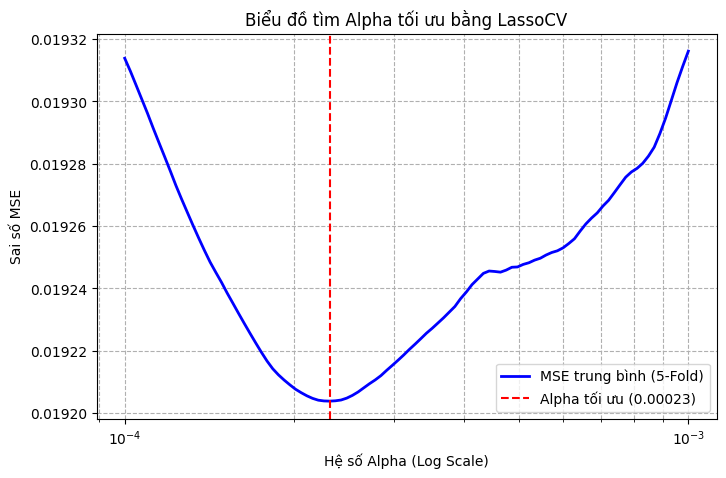

In [9]:
import matplotlib.pyplot as plt

# 1. Lấy danh sách alphas và MSE trung bình tương ứng (LassoCV lưu MSE ở dạng số âm)
alphas = lasso.alphas_
mean_mse = np.mean(lasso.mse_path_, axis=1)

# 2. Vẽ biểu đồ
plt.figure(figsize=(8, 5))
plt.plot(alphas, mean_mse, label='MSE trung bình (5-Fold)', color='blue', lw=2)
plt.axvline(lasso.alpha_, color='red', linestyle='--', label=f'Alpha tối ưu ({round(lasso.alpha_, 5)})')

plt.xscale('log') # Vì alpha quét theo cấp số nhân
plt.xlabel('Hệ số Alpha (Log Scale)')
plt.ylabel('Sai số MSE')
plt.title('Biểu đồ tìm Alpha tối ưu bằng LassoCV')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

#1. Tất cả feature vs. Sàng lọc bằng Lasso (Giữ 81/100)
- Kết quả: Hiệu suất y hệt nhau ($R^2 = 0.638$, $RMSE = 0.132$, $MAE = 0.094$).

- Ý nghĩa: Khi bạn dùng Lasso, mô hình đã tự động loại bỏ đi 19 tính năng (gán hệ số regression bằng 0) nhưng độ chính xác của mô hình không hề giảm đi một chút nào.

- Kết luận: 19 tính năng bị loại bỏ này hoàn toàn là nhiễu (noise) hoặc bị thừa (redundant). Chúng không mang lại giá trị dự báo nào cho mô hình Linear Regression. Việc loại bỏ chúng giúp mô hình của bạn gọn nhẹ hơn, chạy nhanh hơn và giảm nguy cơ bị quá khớp (overfitting) mà không làm mất đi độ chính xác.
#2. Sàng lọc sâu hơn (Chỉ giữ lại 18/100)
- Kết quả: Hiệu suất giảm nhẹ ($R^2$ giảm từ $0.638 \rightarrow 0.619$, $RMSE$ tăng từ $0.132 \rightarrow 0.135$).

- Ý nghĩa: Khi bạn ép mô hình giảm mạnh số lượng tính năng từ 81 xuống chỉ còn 18 (bỏ đi thêm 63 tính năng nữa), mô hình bắt đầu bị mất thông tin.

- Kết luận: Trong số 63 tính năng bị bỏ thêm đó, có chứa những thông tin quan trọng để giải thích cho biến mục tiêu ($y$). Tuy nhiên, bạn hãy nhìn kỹ vào mức độ giảm: $R^2$ chỉ giảm khoảng 1.9% (từ 63.8% xuống 61.9%), một mức giảm rất nhỏ so với việc bạn đã "vứt bớt" tận 63 biến.
#ĐÁNH GIÁ CHUNG: Dữ liệun đang nói lên điều gì?
- Hiện tượng đa cộng tuyến hoặc thừa tính năng (High Dimensionality / Redundancy): Bộ dữ liệu gốc (100 features) của bạn có rất nhiều biến "vô dụng" hoặc các biến bị trùng lặp thông tin với nhau.
- Quy luật 80/20 (Pareto): Chỉ cần 18 tính năng cốt lõi đã đủ để gánh vác tới 61.9% khả năng dự báo của toàn bộ mô hình. Trong khi cần tới 81 tính năng mới đạt được 63.8%.Khả năng của mô hình Tuyến tính (Linear): Với $R^2$ tối đa đạt khoảng 0.638 (giải thích được ~63.8% sự biến thiên của dữ liệu), mô hình Tuyến tính đang ở mức khá ổn nhưng chưa xuất sắc. Có thể mối quan hệ giữa các feature và biến mục tiêu có tính chất phi tuyến (non-linear).

In [10]:
#Các feature mà boruta và lasso cùng giữ lại
common_features = list(set(confirmed_features) & set(kept_features))
print(f"• Các tính năng được cả Boruta và Lasso giữ lại:\n  {common_features}")
boruta_only_features = list(set(confirmed_features) - set(kept_features))
print(f"• Các tính năng chỉ được Boruta giữ lại:\n  {boruta_only_features}")
lasso_only_features = list(set(kept_features) - set(confirmed_features))
print(f"• Các tính năng chỉ được Lasso giữ lại:\n  {lasso_only_features}")

• Các tính năng được cả Boruta và Lasso giữ lại:
  ['PctIlleg', 'PctKids2Par', 'NumStreet', 'PctPopUnderPov', 'NumIlleg', 'FemalePctDiv', 'HousVacant', 'MalePctDivorce', 'racePctWhite', 'PctFam2Par', 'PctHousLess3BR', 'PctUsePubTrans', 'racepctblack', 'pctWInvInc', 'PctPersDenseHous', 'PctSpeakEnglOnly']
• Các tính năng chỉ được Boruta giữ lại:
  ['PctLargHouseFam', 'TotalPctDiv']
• Các tính năng chỉ được Lasso giữ lại:
  ['OwnOccHiQuart', 'MedOwnCostPctIncNoMtg', 'AsianPerCap', 'PctOccupManu', 'racePctHisp', 'blackPerCap', 'PctImmigRec5', 'agePct65up', 'PctWorkMom', 'whitePerCap', 'PersPerRentOccHous', 'PctWorkMomYoungKids', 'PersPerOwnOccHous', 'NumUnderPov', 'PctVacantBoarded', 'PctImmigRecent', 'pctWPubAsst', 'PctHousOccup', 'PctBSorMore', 'PctWOFullPlumb', 'OwnOccLowQuart', 'PctEmploy', 'MedNumBR', 'HispPerCap', 'pctWRetire', 'pctWFarmSelf', 'numbUrban', 'MedRentPctHousInc', 'PctVacMore6Mos', 'MedRent', 'RentLowQ', 'PctLess9thGrade', 'PctTeen2Par', 'PctUnemployed', 'medFamInc', 'P

#**Vì sao Boruta lại xác định có tới 82 biến là nhiễu trong khi Lasso chỉ loại 19 biến?**

Sự khác biệt lớn này xuất phát từ việc Lasso và Boruta định nghĩa thế nào là một đặc trưng "vô giá trị" theo hai cách hoàn toàn khác nhau, cùng với cách vận hành của hai thuật toán.Khi $\alpha$ của Lasso rất nhỏ nhưng chỉ loại bỏ 19/100 đặc trưng, trong khi Boruta loại bỏ tận 82/100 đặc trưng, điều này không mâu thuẫn. Nó phản ánh một hiện tượng rất kinh điển trong Khoa học dữ liệu: Mối quan hệ phi tuyến tính (Non-linear) và sự khác biệt giữa bài toán Tối ưu hóa hàm chi phí so với bài toán Kiểm định giả thuyết.Dưới đây là lý do chi tiết vì sao có sự chênh lệch lớn này:

#1. Lasso tìm mối quan hệ Tuyến tính, Boruta tìm mối quan hệ Phi tuyến tính

**Lasso** (Linear Model): Chỉ nhìn thấy các mối quan hệ tuyến tính (đường thẳng). Nếu một đặc trưng có tương quan tuyến tính dù là rất nhỏ hoặc rất yếu với biến mục tiêu, Lasso với $\alpha$ nhỏ vẫn sẽ giữ lại hệ số của nó (khác 0) để vớt vát thêm một chút độ chính xác cho mô hình.

**Boruta** (Dựa trên Random Forest): Bản chất là các cây quyết định (Tree-based), có khả năng bắt giữ các mối quan hệ phi tuyến tính phức tạp và các tương tác tương hỗ giữa các biến (feature interaction).

**Điều này nói lên gì về Data?** Có thể dữ liệu của bạn chứa rất nhiều biến có mối quan hệ tuyến tính cực kỳ yếu (Lasso giữ lại vì $\alpha$ nhỏ), nhưng khi đưa vào mô hình phi tuyến tính như Random Forest, những biến này hoàn toàn vô dụng so với các biến mạnh khác, hoặc chúng không vượt qua được bài kiểm tra ngẫu nhiên của Boruta.

#2. Bản chất thuật toán: Trừng phạt (Lasso) vs. Đối đầu với bóng ma (Boruta)

**Cơ chế của Boruta rất nghiêm ngặt**: Thuật toán này tạo ra các "biến bóng ma" (Shadow Features) bằng cách xáo trộn ngẫu nhiên (shuffle) dữ liệu của chính các biến gốc. Một biến gốc chỉ được giữ lại nếu nó có độ quan trọng vượt trội hơn hẳn biến shadow tốt nhất dựa trên kiểm định thống kê Z-score.Nếu dữ liệu của bạn có 100 biến, nhưng thực chất chỉ có khoảng dưới 20 biến là có tác động mạnh mẽ, rõ rệt, Boruta sẽ thẳng tay loại bỏ 82 biến còn lại vì hiệu suất của chúng không khác gì một biến bị xáo trộn ngẫu nhiên (nhiễu hoàn toàn).
**Cơ chế của Lasso với $\alpha$ nhỏ rất lỏng lẻo**: Khi $\alpha = 10^{-4}$ hoặc $10^{-3}$, lực phạt của Lasso gần như bằng không. Mô hình lúc này hoạt động gần giống như Hồi quy tuyến tính thông thường (OLS). Nó sẽ cố gắng "ôm đồm" giải thích phân phối của dữ liệu bằng cách gán cho mỗi biến một trọng số $\beta$ rất nhỏ thay vì triệt tiêu nó về 0.

#3. Cách xử lý đa cộng tuyến (Multicollinearity) khác nhau

Nếu trong 100 đặc trưng của bạn có nhiều nhóm biến bị trùng lặp thông tin (tương quan cao với nhau):
**Lasso**: Khi $\alpha$ quá nhỏ, Lasso mất đi khả năng chọn lọc biến đại diện trong nhóm đa cộng tuyến. Thay vì chọn 1 và ép các biến còn lại về 0, nó sẽ giữ lại cả nhóm và chia nhỏ hệ số ra cho từng biến. Đó là lý do số lượng biến bị loại bỏ rất ít (chỉ 19 biến).

**Boruta**: Random Forest (nền tảng của Boruta) xử lý đa cộng tuyến theo cách khác. Khi các biến giống nhau, độ quan trọng của chúng sẽ bị chia sẻ hoặc biến shadow sẽ dễ dàng vượt qua các biến yếu trong nhóm, dẫn đến việc Boruta có xu hướng lọc nghiêm khắc hơn để giữ lại những đại diện thực sự xuất sắc.
#Tổng kết về bản chất bộ dữ liệu của bạn

Kết quả đối nghịch này vẽ nên một bức tranh rất rõ ràng về cấu trúc bộ dữ liệu của bạn:Về số lượng biến thực sự chất lượng: Tập dữ liệu của bạn thực chất khá "cô đọng". Chỉ có khoảng 18–20 đặc trưng là mang thông tin cốt lõi và mạnh mẽ nhất (được cả hai phương pháp xác nhận).Về 82 biến bị Boruta loại bỏ: Phần lớn trong số chúng là các biến có tín hiệu tuyến tính cực kỳ nhiễu hoặc yếu. Lasso vì quá "nhân nhượng" (do $\alpha$ nhỏ) nên đã giữ lại, nhưng bản chất chúng không đóng góp nhiều giá trị cho các mô hình học máy phức tạp.

In [11]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

def get_vif(features):
    X_subset = sm.add_constant(X_train[features])
    return pd.Series([variance_inflation_factor(X_subset.values, i) for i in range(X_subset.shape[1])],
                     index=X_subset.columns).drop('const')

print("VIF Boruta:")
display(get_vif(confirmed_features))

print("\nVIF Lasso:")
display(get_vif(kept_features))

VIF Boruta:


,0
racepctblack,11.492320
racePctWhite,12.272895
pctWInvInc,4.180403
PctPopUnderPov,4.132292
MalePctDivorce,194.566169
FemalePctDiv,307.090817
TotalPctDiv,933.257987
PctFam2Par,66.860603
PctKids2Par,68.252278
NumIlleg,4.852297



VIF Lasso:


,0
householdsize,22.146463
racepctblack,18.513252
racePctWhite,21.033692
racePctAsian,5.499985
racePctHisp,17.724795
...,...
PctSameCity85,5.226238
PctSameState85,7.643117
LandArea,2.779750
PctUsePubTrans,2.940749
